In [1]:
from scipy.interpolate import RegularGridInterpolator
import numpy as np

In [25]:
from matplotlib.colors import ListedColormap
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt


def pcolor_plot(AX, X, Y, C, title,colormap="copper",set_axis = 'on',colorbar=True,**kwargs):
    ## plot the pcolor plot of the given data C on the given axis AX with the given title and optional colorbar limits cmin and cmax
    formatter = ticker.ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-3, 3))
    if len(kwargs) == 0:
        im = AX.pcolor(X, Y, C, cmap=colormap,shading='auto')
    else:
        cmin = kwargs["cmin"]
        cmax = kwargs["cmax"]
        im = AX.pcolor(X, Y, C, cmap=colormap, vmin=cmin, vmax=cmax,shading='auto')
    AX.set_aspect("equal", "box")
    AX.axis(set_axis)
    AX.set_title(title, fontsize=14)
    plt.colorbar(im, ax=AX, format=formatter)
    return im

cmap = plt.get_cmap('viridis')
num_colors = 30
color_values = [cmap(i) for i in np.linspace(0, 1, num_colors)]
cmap = ListedColormap(color_values)

In [34]:
from scipy.interpolate import RegularGridInterpolator

plate_size = 100
fem_solutions = []
for n_node in [20,50,100,200,500]:
    data_path = f"{n_node}x{n_node}nodes"
    # Load solution
    data = np.loadtxt(data_path+".dat", delimiter=" ")
    X_val = data[:, :2]
    u_val = data[:, 2:4]
    stress_val = data[:, 7:10]

    solution_val = np.hstack((u_val, stress_val))

    n_mesh_points = int(np.sqrt(X_val.shape[0]))

    # Interpolate solution
    x_grid = np.linspace(0, plate_size, n_mesh_points)
    y_grid = np.linspace(0, plate_size, n_mesh_points)

    interpolators = []
    for i in range(solution_val.shape[1]):
        interp = RegularGridInterpolator((x_grid, y_grid), solution_val[:, i].reshape(n_mesh_points, n_mesh_points).T)
        interpolators.append(interp)

    solution_fn = (lambda interpolators: 
                   lambda x, y: np.array([interp((x, y)) for interp in interpolators]).T)(interpolators)
    fem_solutions.append(solution_fn)   

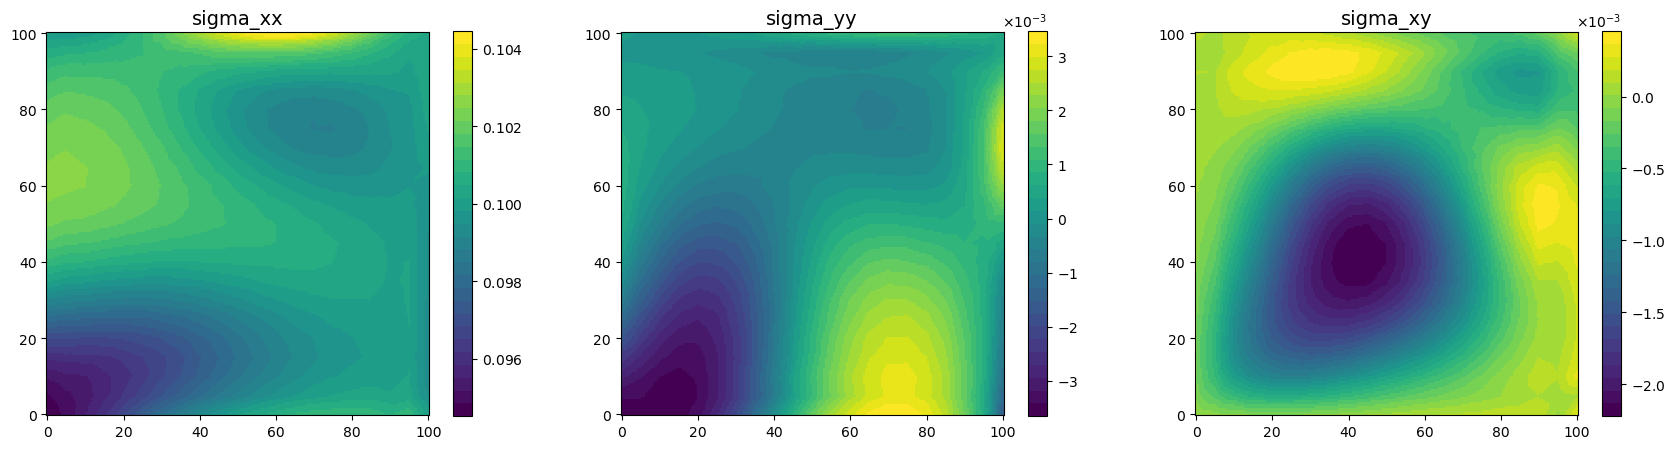

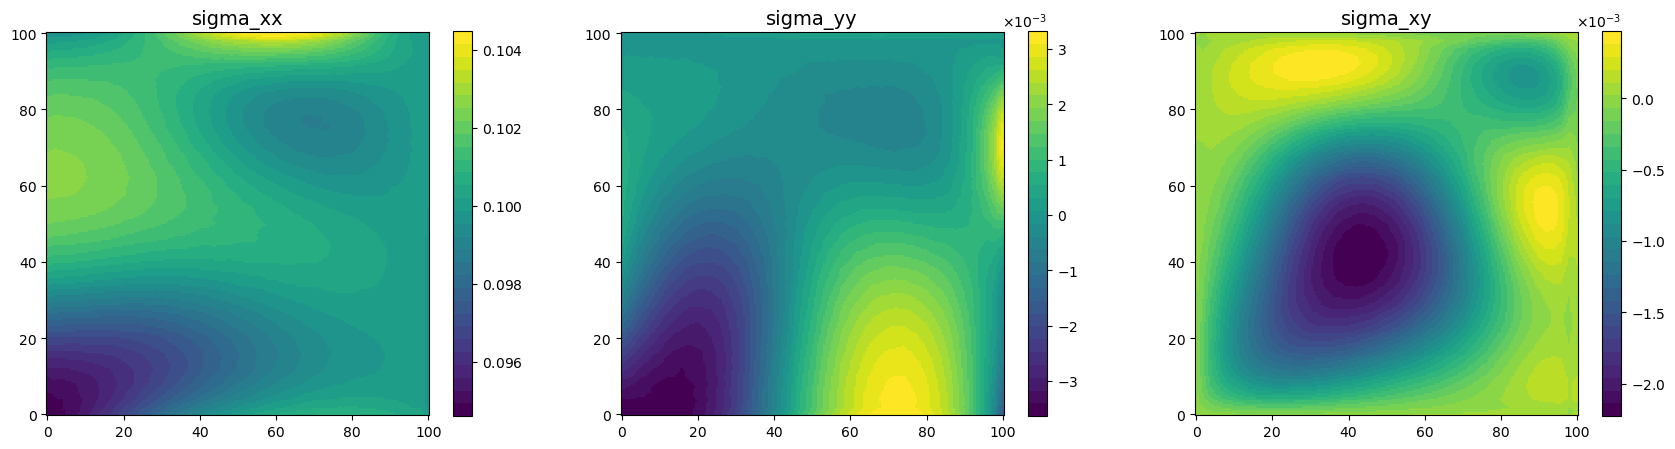

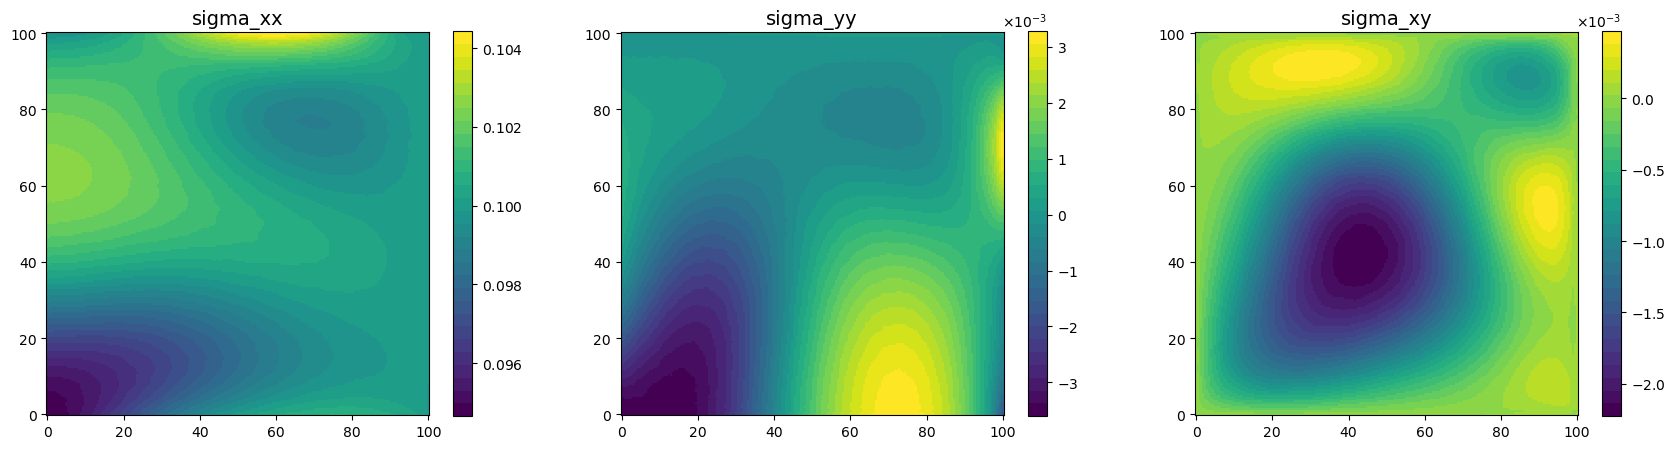

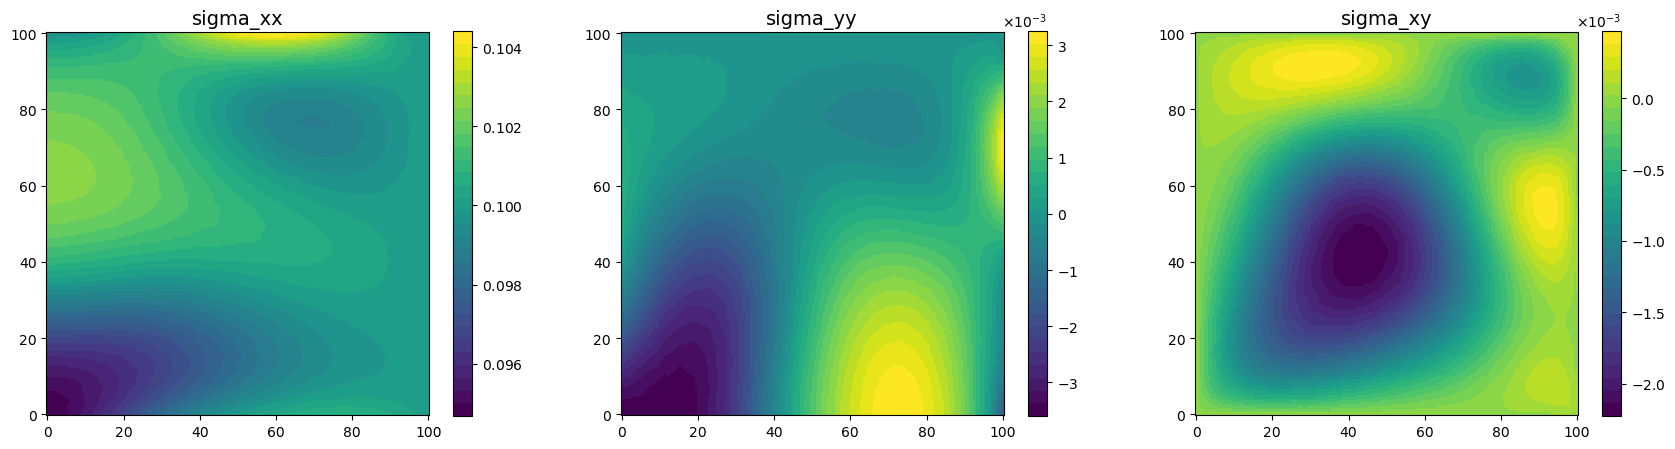

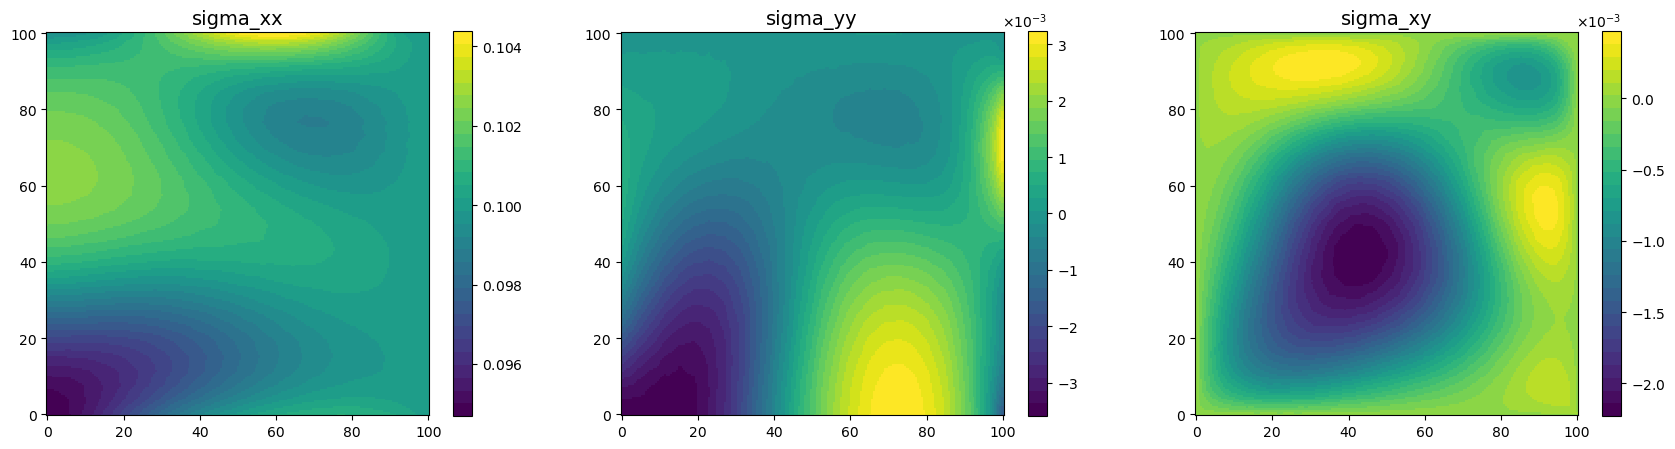

In [36]:
n_plot_points = 200
x_plot = np.linspace(0, plate_size, n_plot_points)
y_plot = np.linspace(0, plate_size, n_plot_points)
X, Y = np.meshgrid(x_plot, y_plot)
X_grid = np.hstack((X.flatten()[:, None], Y.flatten()[:, None]))

for solution_fn in fem_solutions:
    solution_plot = solution_fn(X_grid[:, 0], X_grid[:, 1])

    # fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    # im = pcolor_plot(ax[0], X, Y, solution_plot[:,0].reshape(X.shape), "u_x",colormap=cmap)
    # im = pcolor_plot(ax[1], X, Y, solution_plot[:,1].reshape(X.shape), "u_y",colormap=cmap)

    fig, ax = plt.subplots(1, 3, figsize=(21, 5))
    im = pcolor_plot(ax[0], X, Y, solution_plot[:,2].reshape(X.shape), "sigma_xx",colormap=cmap)
    im = pcolor_plot(ax[1], X, Y, solution_plot[:,3].reshape(X.shape), "sigma_yy",colormap=cmap)
    im = pcolor_plot(ax[2], X, Y, solution_plot[:,4].reshape(X.shape), "sigma_xy",colormap=cmap)

0.0021699425201466838
0.0005073483015469726
0.00018403169027967448
9.138844891398712e-05


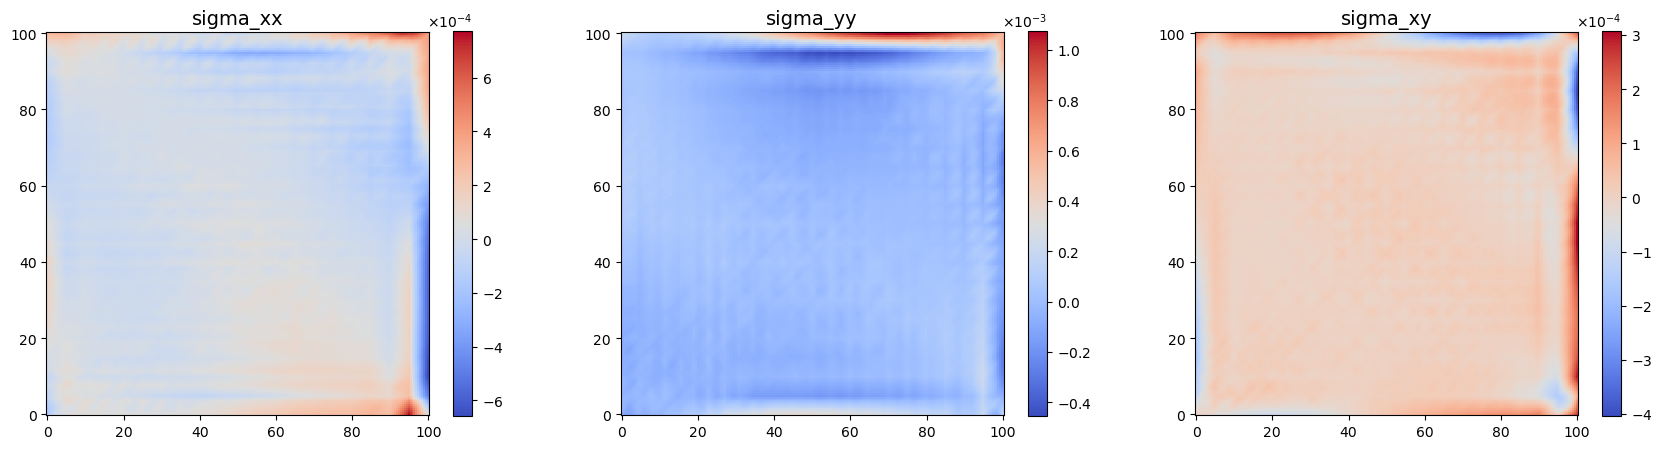

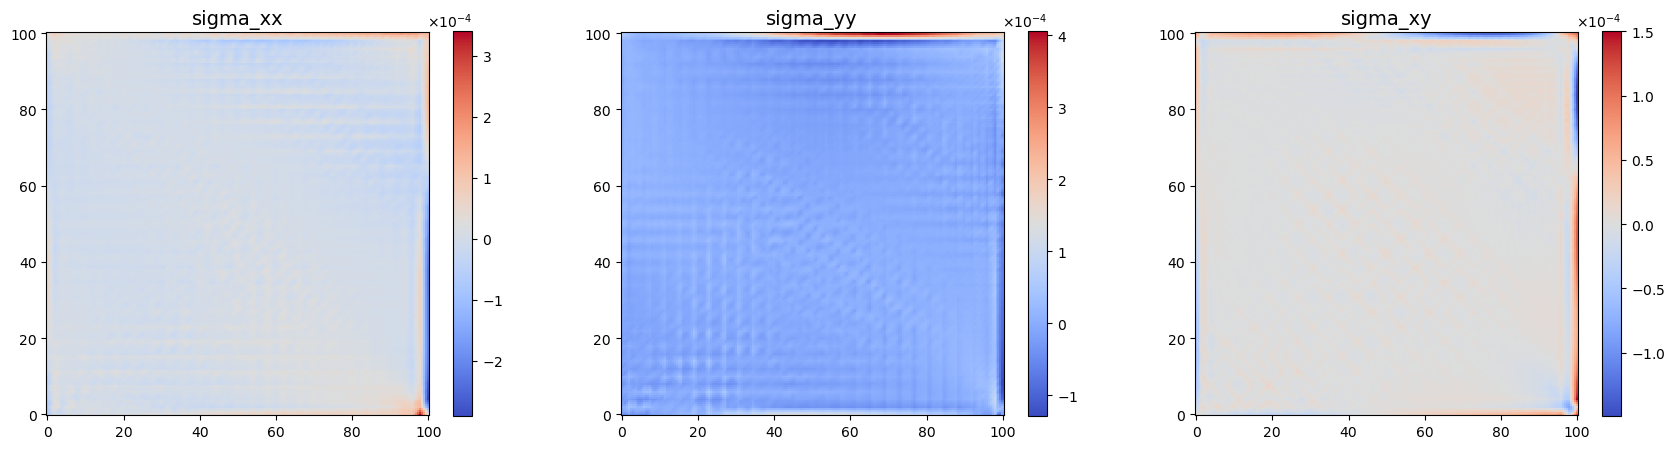

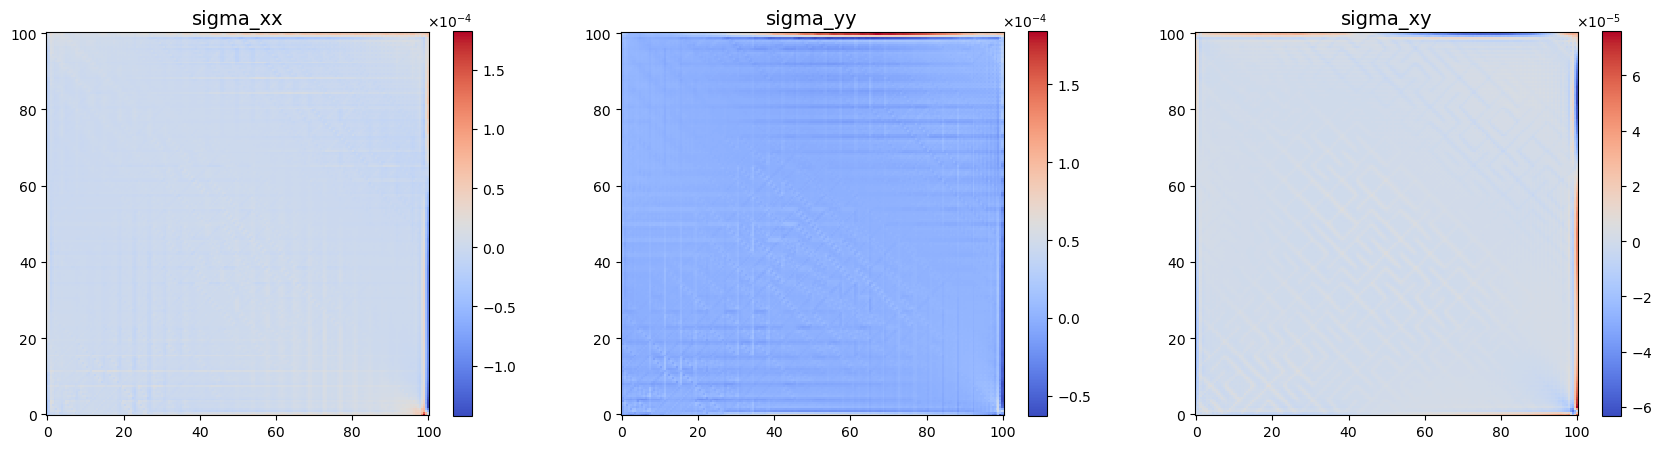

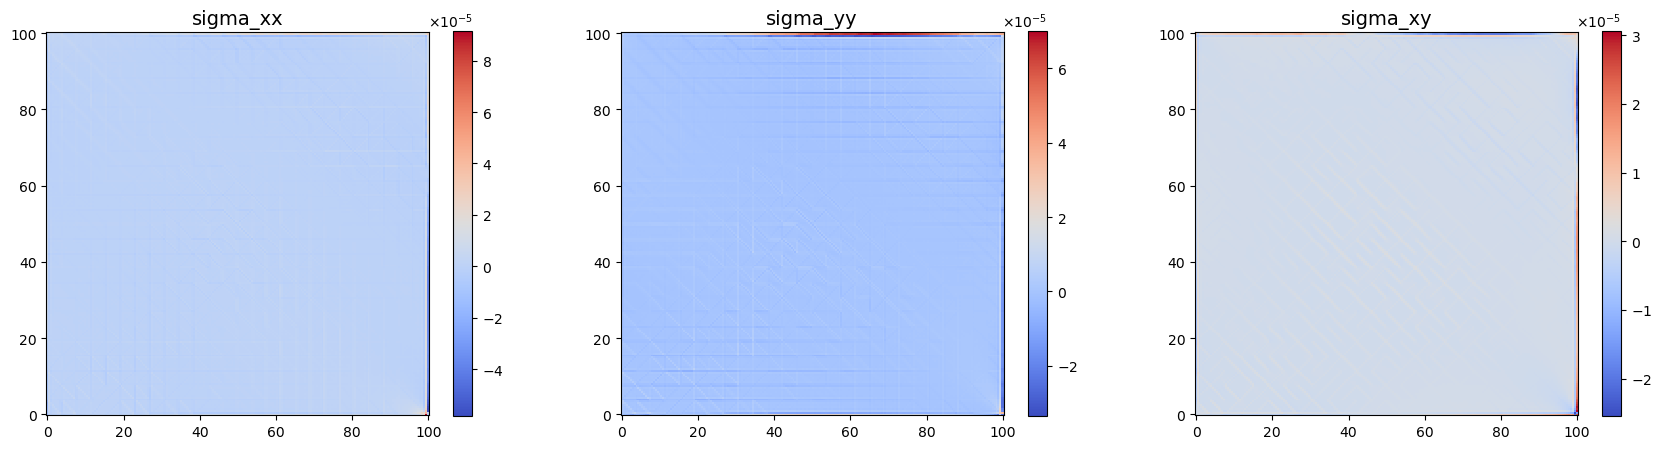

In [37]:
solution_500 = fem_solutions[-1]

for solution_fn in fem_solutions[:-1]:
    solution_plot = solution_fn(X_grid[:, 0], X_grid[:, 1])
    solution_500_plot = solution_500(X_grid[:, 0], X_grid[:, 1])

    fig, ax = plt.subplots(1, 3, figsize=(21, 5))
    im = pcolor_plot(ax[0], X, Y, solution_plot[:,2].reshape(X.shape)-solution_500_plot[:,2].reshape(X.shape), "sigma_xx",colormap="coolwarm")
    im = pcolor_plot(ax[1], X, Y, solution_plot[:,3].reshape(X.shape)-solution_500_plot[:,3].reshape(X.shape), "sigma_yy",colormap="coolwarm")
    im = pcolor_plot(ax[2], X, Y, solution_plot[:,4].reshape(X.shape)-solution_500_plot[:,4].reshape(X.shape), "sigma_xy",colormap="coolwarm")
    print(np.max(np.abs(solution_plot-solution_500_plot)))